### Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

### Load Dataset

In [3]:
# Read dataset csv
df = pd.read_csv("transactions.csv")
df.head()

,transaction_id,user_id,account_age_days,total_transactions_user,avg_amount_user,amount,country,bin_country,channel,merchant_category,promo_used,avs_match,cvv_result,three_ds_flag,transaction_time,shipping_distance_km,is_fraud
0,1,1,141,47,147.93,84.75,FR,FR,web,travel,0,1,1,1,2024-01-06T04:09:39Z,370.95,0
1,2,1,141,47,147.93,107.90,FR,FR,web,travel,0,0,0,0,2024-01-09T20:13:47Z,149.62,0
2,3,1,141,47,147.93,92.36,FR,FR,app,travel,1,1,1,1,2024-01-12T06:20:11Z,164.08,0
3,4,1,141,47,147.93,112.47,FR,FR,web,fashion,0,1,1,1,2024-01-15T17:00:04Z,397.40,0
4,5,1,141,47,147.93,132.91,FR,US,web,electronics,0,1,1,1,2024-01-17T01:27:31Z,935.28,0


### Problem & Dataset Understanding

Membangun model untuk mengidentifikasi transaksi yang berpotensi fraud berdasarkan karakteristik transaksi, user, payment verification, channel dan lokasi.

Target: [is_fraud] 0 = non fraud | 1 = fraud

In [4]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Shape: (9999, 17)

Columns:
['transaction_id', 'user_id', 'account_age_days', 'total_transactions_user', 'avg_amount_user', 'amount', 'country', 'bin_country', 'channel', 'merchant_category', 'promo_used', 'avs_match', 'cvv_result', 'three_ds_flag', 'transaction_time', 'shipping_distance_km', 'is_fraud']

Data Types:
transaction_id               int64
user_id                      int64
account_age_days             int64
total_transactions_user      int64
avg_amount_user            float64
amount                     float64
country                     object
bin_country                 object
channel                     object
merchant_category           object
promo_used                   int64
avs_match                    int64
cvv_result                   int64
three_ds_flag                int64
transaction_time            object
shipping_distance_km       float64
is_fraud                     int64
dtype: object


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9999 entries, 0 to 9998
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           9999 non-null   int64  
 1   user_id                  9999 non-null   int64  
 2   account_age_days         9999 non-null   int64  
 3   total_transactions_user  9999 non-null   int64  
 4   avg_amount_user          9999 non-null   float64
 5   amount                   9999 non-null   float64
 6   country                  9999 non-null   object 
 7   bin_country              9999 non-null   object 
 8   channel                  9999 non-null   object 
 9   merchant_category        9999 non-null   object 
 10  promo_used               9999 non-null   int64  
 11  avs_match                9999 non-null   int64  
 12  cvv_result               9999 non-null   int64  
 13  three_ds_flag            9999 non-null   int64  
 14  transaction_time        

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
transaction_id,9999.0,5000.000000,2886.607005,1.00,2500.500,5000.00,7499.500,9999.00
user_id,9999.0,100.491849,58.252421,1.00,49.000,100.00,151.000,201.00
account_age_days,9999.0,1022.828883,519.212191,10.00,566.000,1085.00,1449.000,1888.00
total_transactions_user,9999.0,50.516552,5.825915,40.00,46.000,51.00,56.000,60.00
avg_amount_user,9999.0,136.492350,169.633322,6.56,44.060,90.48,147.930,1366.72
amount,9999.0,162.679380,265.747270,1.16,41.840,87.68,174.635,3883.46
promo_used,9999.0,0.149015,0.356121,0.00,0.000,0.00,0.000,1.00
avs_match,9999.0,0.842184,0.364586,0.00,1.000,1.00,1.000,1.00
cvv_result,9999.0,0.879688,0.325342,0.00,1.000,1.00,1.000,1.00
three_ds_flag,9999.0,0.782778,0.412375,0.00,1.000,1.00,1.000,1.00


### Data Quality

In [7]:
missing = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percentage": df.isnull().mean() * 100
})

missing = missing.sort_values(
    "missing_count",
    ascending=False
)

missing

,missing_count,missing_percentage
transaction_id,0,0.0
user_id,0,0.0
account_age_days,0,0.0
total_transactions_user,0,0.0
avg_amount_user,0,0.0
amount,0,0.0
country,0,0.0
bin_country,0,0.0
channel,0,0.0
merchant_category,0,0.0


In [8]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate transaction_id:", df["transaction_id"].duplicated().sum())

Duplicate rows: 0
Duplicate transaction_id: 0


In [9]:
df.nunique().sort_values()

cvv_result                    2
avs_match                     2
promo_used                    2
three_ds_flag                 2
channel                       2
is_fraud                      2
merchant_category             5
country                      10
bin_country                  10
total_transactions_user      21
account_age_days            193
avg_amount_user             200
user_id                     201
amount                     8263
shipping_distance_km       9161
transaction_time           9998
transaction_id             9999
dtype: int64

In [10]:
df["transaction_time"] = pd.to_datetime(
    df["transaction_time"],
    errors="coerce"
)
df.dtypes

transaction_id                           int64
user_id                                  int64
account_age_days                         int64
total_transactions_user                  int64
avg_amount_user                        float64
amount                                 float64
country                                 object
bin_country                             object
channel                                 object
merchant_category                       object
promo_used                               int64
avs_match                                int64
cvv_result                               int64
three_ds_flag                            int64
transaction_time           datetime64[ns, UTC]
shipping_distance_km                   float64
is_fraud                                 int64
dtype: object

In [11]:
df["transaction_time"].isna().sum()

0

### Univariate Analysis

In [12]:
numeric_cols = [
    "total_transactions_user",
    "account_age_days",
    "avg_amount_user",
    "amount",
    "shipping_distance_km"
]

#### 1. Summary Statistics

In [13]:
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
total_transactions_user,9999.0,50.516552,5.825915,40.00,46.000,51.00,56.000,60.00
account_age_days,9999.0,1022.828883,519.212191,10.00,566.000,1085.00,1449.000,1888.00
avg_amount_user,9999.0,136.492350,169.633322,6.56,44.060,90.48,147.930,1366.72
amount,9999.0,162.679380,265.747270,1.16,41.840,87.68,174.635,3883.46
shipping_distance_km,9999.0,351.895818,416.013336,0.07,135.515,273.47,407.645,3715.80


In [14]:
summary = df[numeric_cols].describe().T
summary["median"] = df[numeric_cols].median()
summary

,count,mean,std,min,25%,50%,75%,max,median
total_transactions_user,9999.0,50.516552,5.825915,40.00,46.000,51.00,56.000,60.00,51.00
account_age_days,9999.0,1022.828883,519.212191,10.00,566.000,1085.00,1449.000,1888.00,1085.00
avg_amount_user,9999.0,136.492350,169.633322,6.56,44.060,90.48,147.930,1366.72,90.48
amount,9999.0,162.679380,265.747270,1.16,41.840,87.68,174.635,3883.46,87.68
shipping_distance_km,9999.0,351.895818,416.013336,0.07,135.515,273.47,407.645,3715.80,273.47


#### 2. Mean vs Median

In [15]:
df[numeric_cols].agg(["mean", "median", "std", "min", "max"]).T

,mean,median,std,min,max
total_transactions_user,50.516552,51.00,5.825915,40.00,60.00
account_age_days,1022.828883,1085.00,519.212191,10.00,1888.00
avg_amount_user,136.492350,90.48,169.633322,6.56,1366.72
amount,162.679380,87.68,265.747270,1.16,3883.46
shipping_distance_km,351.895818,273.47,416.013336,0.07,3715.80


#### 3. Skewness

sekitar 0 = relatif symmetric |
lebih dari 0 = right-skewed |
kurang dari 0 = left-skewed |
0 - 0.5 = relatively low skew |
0.5 - 1 = moderate skew |
lebih dari 1 = strong skew

In [16]:
df[numeric_cols].skew().sort_values(ascending=False)

amount                     5.597721
avg_amount_user            3.926146
shipping_distance_km       3.511942
total_transactions_user   -0.110570
account_age_days          -0.120631
dtype: float64

#### 4. IQR (Interquartile Range)

In [17]:
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)

IQR = Q3 = Q1

iqr_summary = pd.DataFrame({
    "Q1": Q1,
    "Q3": Q3,
    "IQR": IQR
})

iqr_summary

,Q1,Q3,IQR
total_transactions_user,46.000,46.000,46.000
account_age_days,566.000,566.000,566.000
avg_amount_user,44.060,44.060,44.060
amount,41.840,41.840,41.840
shipping_distance_km,135.515,135.515,135.515


#### Numerical Visualization

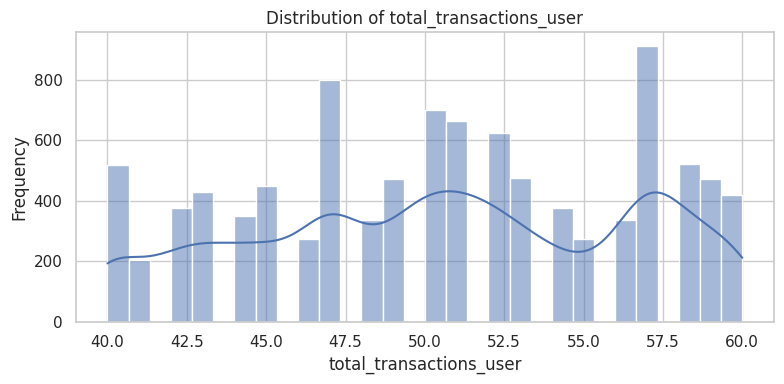

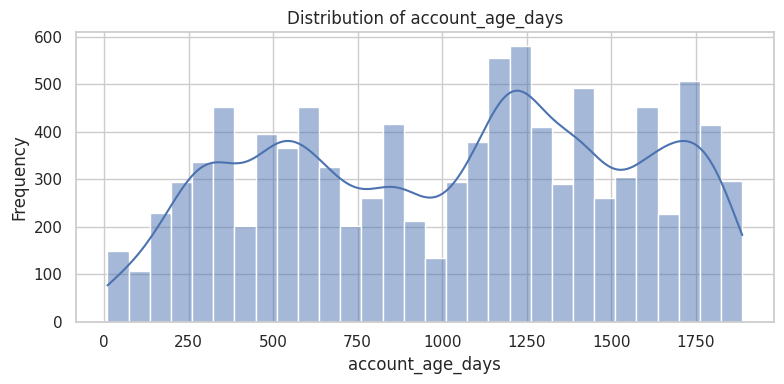

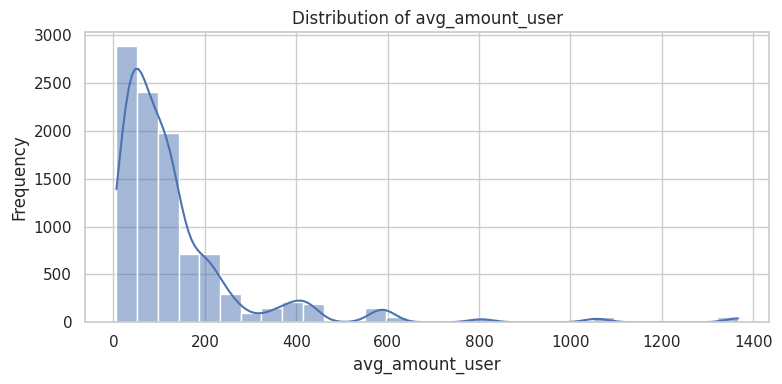

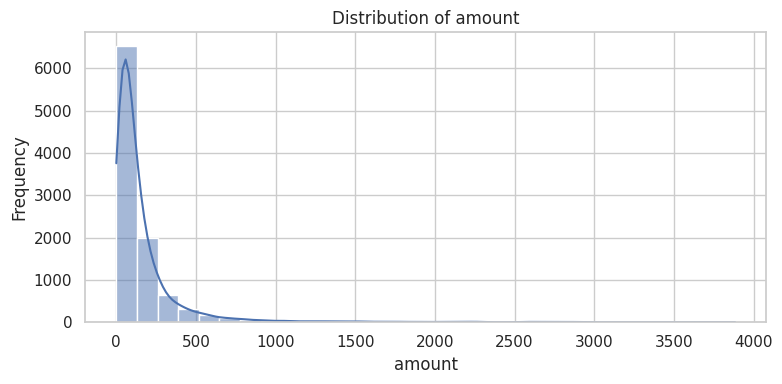

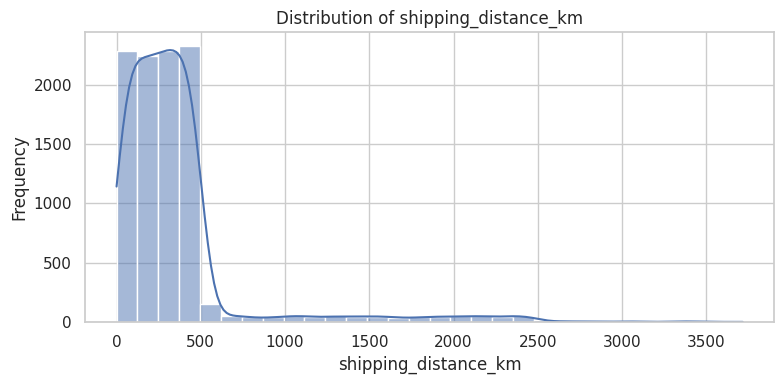

In [18]:
for col in numeric_cols:
    plt.figure(figsize=(8,4))

    sns.histplot(
        data = df,
        x = col,
        bins = 30,
        kde = True
    )

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

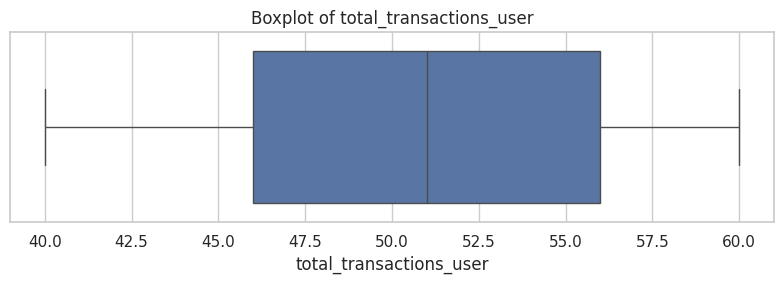

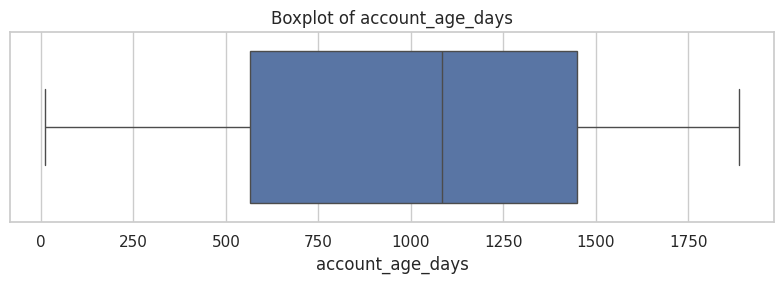

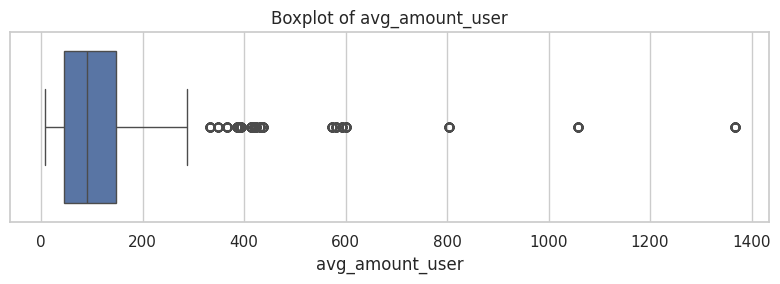

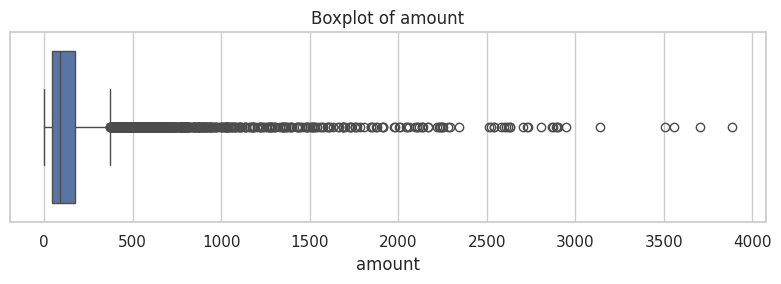

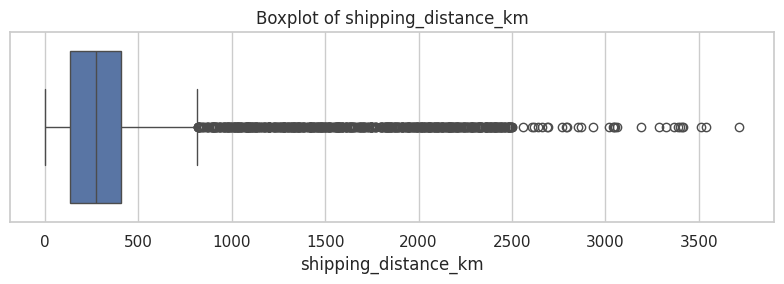

In [19]:
for col in numeric_cols:
    plt.figure(figsize=(8,3))

    sns.boxplot(
        data = df,
        x = col
    )

    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show

#### Univariate Analysis - Categorical

In [20]:
categorical_cols = [
    "country",
    "bin_country",
    "channel",
    "merchant_category",
    "promo_used",
    "avs_match",
    "cvv_result",
    "three_ds_flag"
]

In [21]:
# frequency
for col in categorical_cols:
    display(df[col].value_counts(dropna=False))
    print("\n")

country
FR    1453
US    1094
NL    1092
RO    1056
PL    1018
TR     989
ES     978
DE     903
IT     735
GB     681
Name: count, dtype: int64

bin_country
FR    1430
US    1093
NL    1082
RO    1042
PL    1018
ES    1005
TR     976
DE     912
IT     759
GB     682
Name: count, dtype: int64

channel
web    5018
app    4981
Name: count, dtype: int64

merchant_category
electronics    2030
travel         2009
fashion        1994
grocery        1990
gaming         1976
Name: count, dtype: int64

promo_used
0    8509
1    1490
Name: count, dtype: int64

avs_match
1    8421
0    1578
Name: count, dtype: int64

cvv_result
1    8796
0    1203
Name: count, dtype: int64

three_ds_flag
1    7827
0    2172
Name: count, dtype: int64

In [22]:
# percentage
for col in categorical_cols:
    display(
        (df[col].value_counts(normalize=True, dropna=False) * 100).round(2)
    )

country
FR    14.53
US    10.94
NL    10.92
RO    10.56
PL    10.18
TR     9.89
ES     9.78
DE     9.03
IT     7.35
GB     6.81
Name: proportion, dtype: float64

bin_country
FR    14.30
US    10.93
NL    10.82
RO    10.42
PL    10.18
ES    10.05
TR     9.76
DE     9.12
IT     7.59
GB     6.82
Name: proportion, dtype: float64

channel
web    50.19
app    49.81
Name: proportion, dtype: float64

merchant_category
electronics    20.30
travel         20.09
fashion        19.94
grocery        19.90
gaming         19.76
Name: proportion, dtype: float64

promo_used
0    85.1
1    14.9
Name: proportion, dtype: float64

avs_match
1    84.22
0    15.78
Name: proportion, dtype: float64

cvv_result
1    87.97
0    12.03
Name: proportion, dtype: float64

three_ds_flag
1    78.28
0    21.72
Name: proportion, dtype: float64

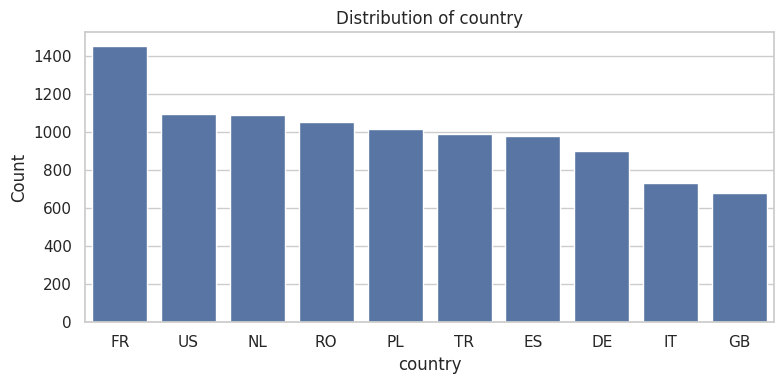

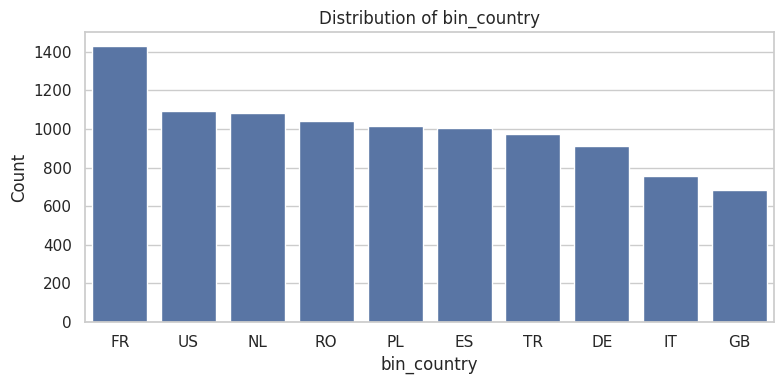

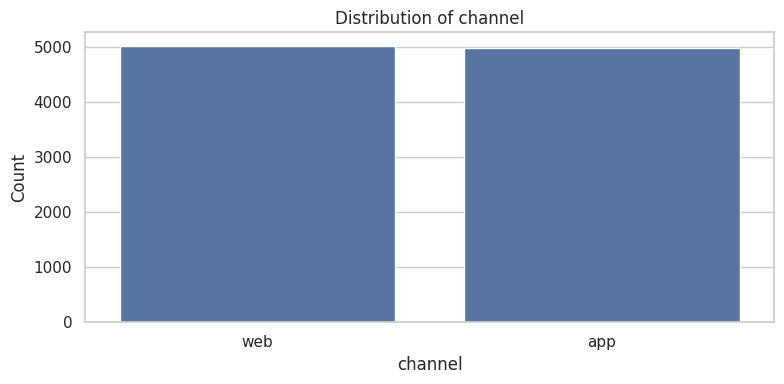

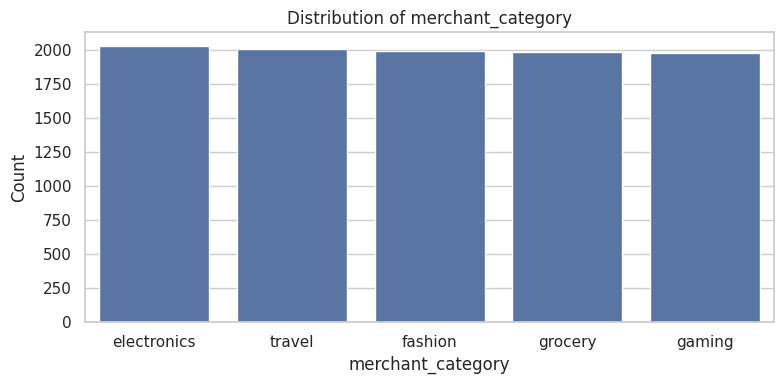

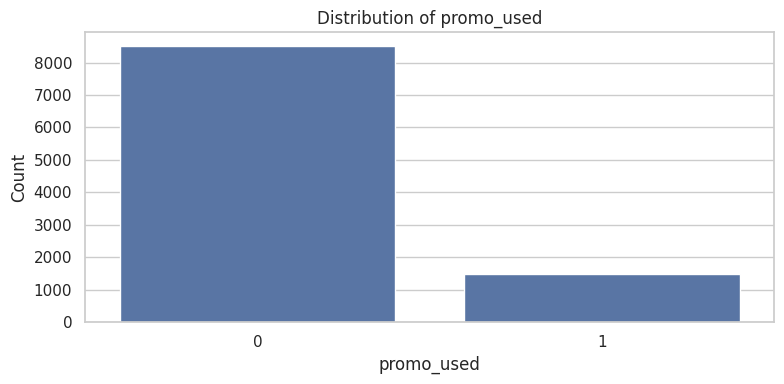

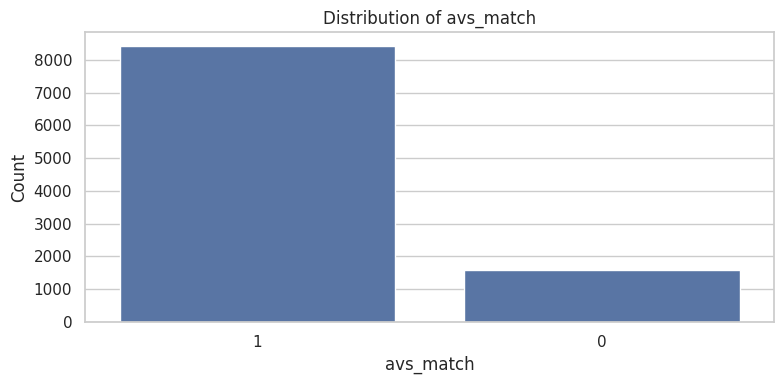

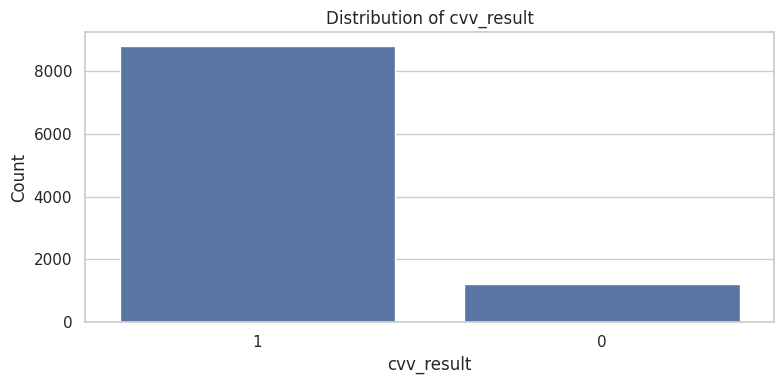

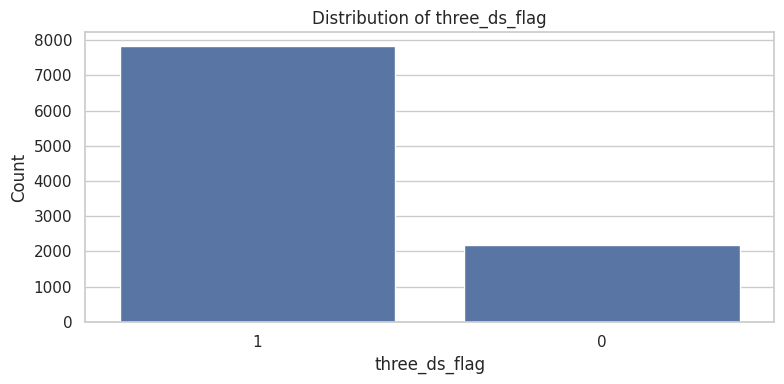

In [23]:
# bar chart
for col in categorical_cols:
    plt.figure(figsize=(8,4))

    order = df[col].value_counts().index

    sns.countplot(
        data = df,
        x = col,
        order = order
    )

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

In [24]:
df["is_fraud"].value_counts()

is_fraud
0    9818
1     181
Name: count, dtype: int64

In [25]:
# percentage
fraud_distribution = (
    df["is_fraud"].value_counts(normalize=True).mul(100).round(2)
)

fraud_distribution

is_fraud
0    98.19
1     1.81
Name: proportion, dtype: float64

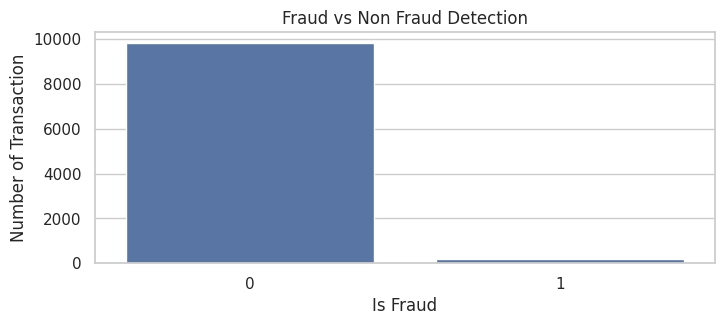

In [26]:
plt.figure(figsize=(8,3))

sns.countplot(
    data = df,
    x = "is_fraud"
)

plt.title("Fraud vs Non Fraud Detection")
plt.xlabel("Is Fraud")
plt.ylabel("Number of Transaction")

plt.show()

Imbalanced Data

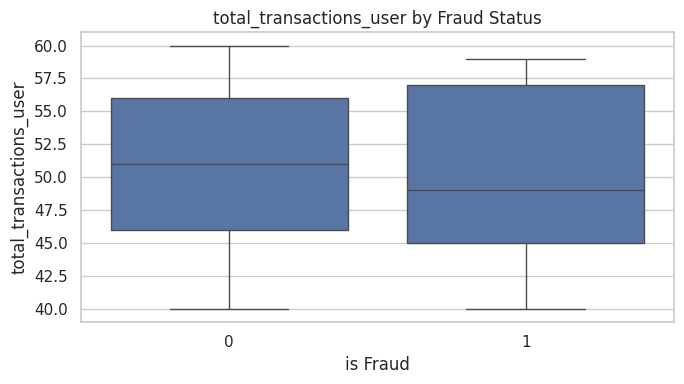

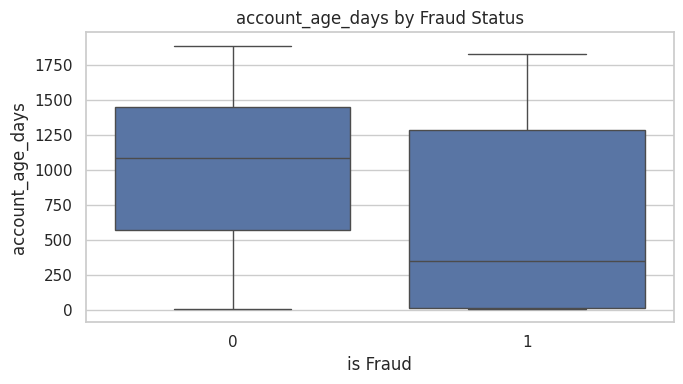

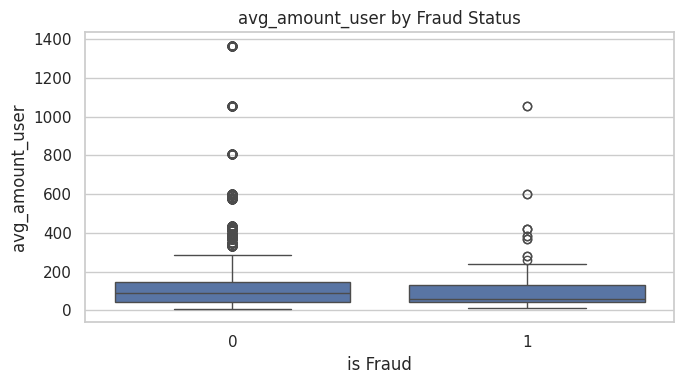

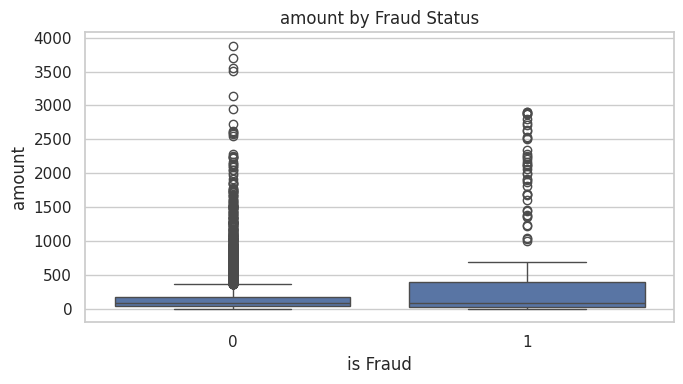

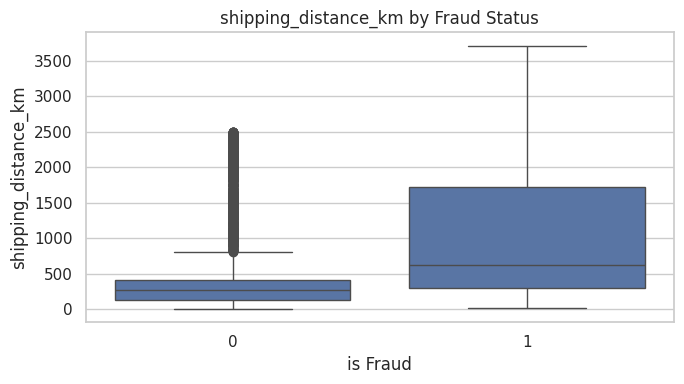

In [27]:
for col in numeric_cols:
    plt.figure(figsize=(7,4))

    sns.boxplot(
        data = df,
        x = "is_fraud",
        y = col
    )

    plt.title(f"{col} by Fraud Status")
    plt.xlabel("is Fraud")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

#### Violin

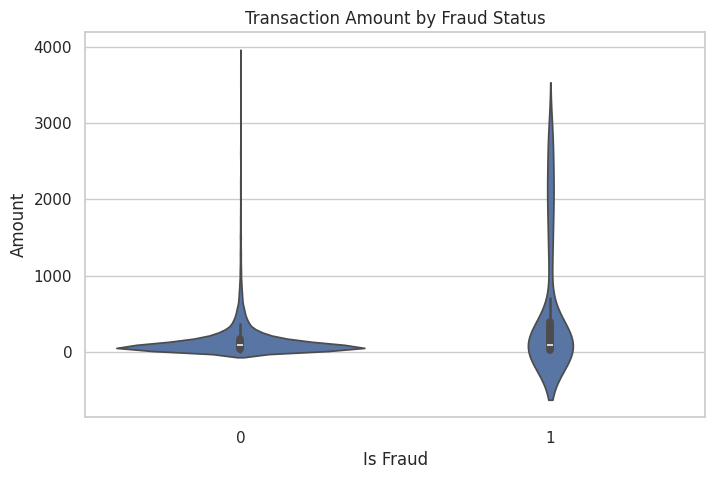

In [28]:
plt.figure(figsize=(8,5))

sns.violinplot(
    data = df,
    x = "is_fraud",
    y = "amount"
)

plt.title("Transaction Amount by Fraud Status")
plt.xlabel("Is Fraud")
plt.ylabel("Amount")

plt.show()

#### Fraud Rate

In [29]:
pd.crosstab(
    df["channel"],
    df["is_fraud"]
)

is_fraud,0,1
channel,,
app,4957,24
web,4861,157


Fraud rate di web lebih tinggi dibandingkan app

In [30]:
# fraud rate
fraud_rate_channel = (
    df.groupby("channel")["is_fraud"].mean().mul(100).round(2).sort_values(ascending=False)
)
fraud_rate_channel

channel
web    3.13
app    0.48
Name: is_fraud, dtype: float64

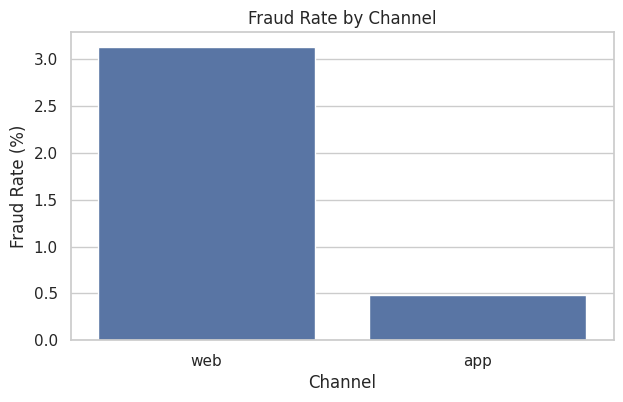

In [31]:
plt.figure(figsize=(7,4))

sns.barplot(
    x = fraud_rate_channel.index,
    y = fraud_rate_channel.values
)

plt.title("Fraud Rate by Channel")
plt.xlabel("Channel")
plt.ylabel("Fraud Rate (%)")

plt.show()

In [32]:
for col in categorical_cols:
    fraud_rate = (
        df.groupby(col)["is_fraud"]
        .mean()
        .mul(100)
        .sort_values(ascending=False)
    )

    print(f"Fraud Rate by {col}")
    display(fraud_rate)

Fraud Rate by country


country
GB    5.873715
US    3.473492
FR    1.927047
IT    1.768707
ES    1.329243
DE    1.328904
NL    1.007326
RO    0.946970
TR    0.808898
PL    0.785855
Name: is_fraud, dtype: float64

Fraud Rate by bin_country


bin_country
GB    4.545455
US    3.019213
IT    2.766798
FR    1.678322
DE    1.535088
PL    1.473477
ES    1.393035
RO    1.343570
TR    0.819672
NL    0.646950
Name: is_fraud, dtype: float64

Fraud Rate by channel


...

avs_match
0    7.921420
1    0.665004
Name: is_fraud, dtype: float64

Fraud Rate by cvv_result


cvv_result
0    8.977556
1    0.829923
Name: is_fraud, dtype: float64

Fraud Rate by three_ds_flag


three_ds_flag
0    5.386740
1    0.817682
Name: is_fraud, dtype: float64

#### Contingency Table

In [33]:
pd.crosstab(
    df["channel"],
    df["is_fraud"],
    margins=True
)

is_fraud,0,1,All
channel,,,
app,4957,24,4981
web,4861,157,5018
All,9818,181,9999


In [34]:
pd.crosstab(
    df["channel"],
    df["is_fraud"],
    normalize="index"
).mul(100).round(2)

is_fraud,0,1
channel,,
app,99.52,0.48
web,96.87,3.13


#### Correlation Numerical

In [35]:
df[numeric_cols].corr()

,total_transactions_user,account_age_days,avg_amount_user,amount,shipping_distance_km
total_transactions_user,1.000000,-0.008085,0.067411,0.057011,-0.001721
account_age_days,-0.008085,1.000000,0.054076,0.017999,-0.030888
avg_amount_user,0.067411,0.054076,1.000000,0.730625,-0.016165
amount,0.057011,0.017999,0.730625,1.000000,0.035730
shipping_distance_km,-0.001721,-0.030888,-0.016165,0.035730,1.000000


In [36]:
corr = df[numeric_cols + ["is_fraud"]].corr()
corr

,total_transactions_user,account_age_days,avg_amount_user,amount,shipping_distance_km,is_fraud
total_transactions_user,1.000000,-0.008085,0.067411,0.057011,-0.001721,-0.010752
account_age_days,-0.008085,1.000000,0.054076,0.017999,-0.030888,-0.099006
avg_amount_user,0.067411,0.054076,1.000000,0.730625,-0.016165,-0.018877
amount,0.057011,0.017999,0.730625,1.000000,0.035730,0.201315
shipping_distance_km,-0.001721,-0.030888,-0.016165,0.035730,1.000000,0.242281
is_fraud,-0.010752,-0.099006,-0.018877,0.201315,0.242281,1.000000


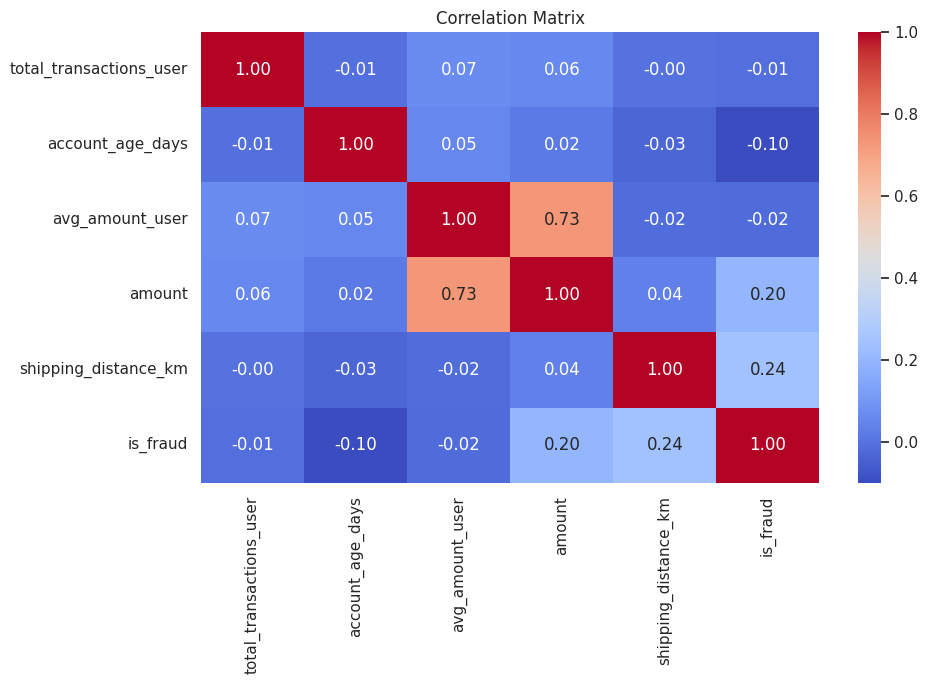

In [37]:
plt.figure(figsize=(10,7))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

0 not fraud | 1 is fraud

#### Categorical Association 

In [38]:
from scipy.stats import chi2_contingency

def cramers_v(x,y):
    table = pd.crosstab(x,y)

    chi2 = chi2_contingency(table, correction=False)[0]
    n = table.sum().sum()

    phi2 = chi2 / n

    r, k = table.shape

    return np.sqrt(
        phi2 / min(k-1, r-1)
    )

In [39]:
cat_corr = pd.DataFrame(
    index = categorical_cols,
    columns = categorical_cols,
    dtype = float
)

for col1 in categorical_cols:
    for col2 in categorical_cols:
        cat_corr.loc[col1, col2] = cramers_v(
            df[col1],
            df[col2]
        )

cat_corr

,country,bin_country,channel,merchant_category,promo_used,avs_match,cvv_result,three_ds_flag
country,1.000000,0.915130,0.037359,0.031447,0.025210,0.037792,0.024748,0.022111
bin_country,0.915130,1.000000,0.037746,0.029848,0.027885,0.034927,0.027528,0.021731
channel,0.037359,0.037746,1.000000,0.014702,0.006315,0.032963,0.017384,0.018909
merchant_category,0.031447,0.029848,0.014702,1.000000,0.010594,0.017214,0.017409,0.010935
promo_used,0.025210,0.027885,0.006315,0.010594,1.000000,0.009132,0.011451,0.007723
avs_match,0.037792,0.034927,0.032963,0.017214,0.009132,1.000000,0.506062,0.220351
cvv_result,0.024748,0.027528,0.017384,0.017409,0.011451,0.506062,1.000000,0.441851
three_ds_flag,0.022111,0.021731,0.018909,0.010935,0.007723,0.220351,0.441851,1.000000


Mendekati 0 = lemah  |  Mendekati 1 = kuat

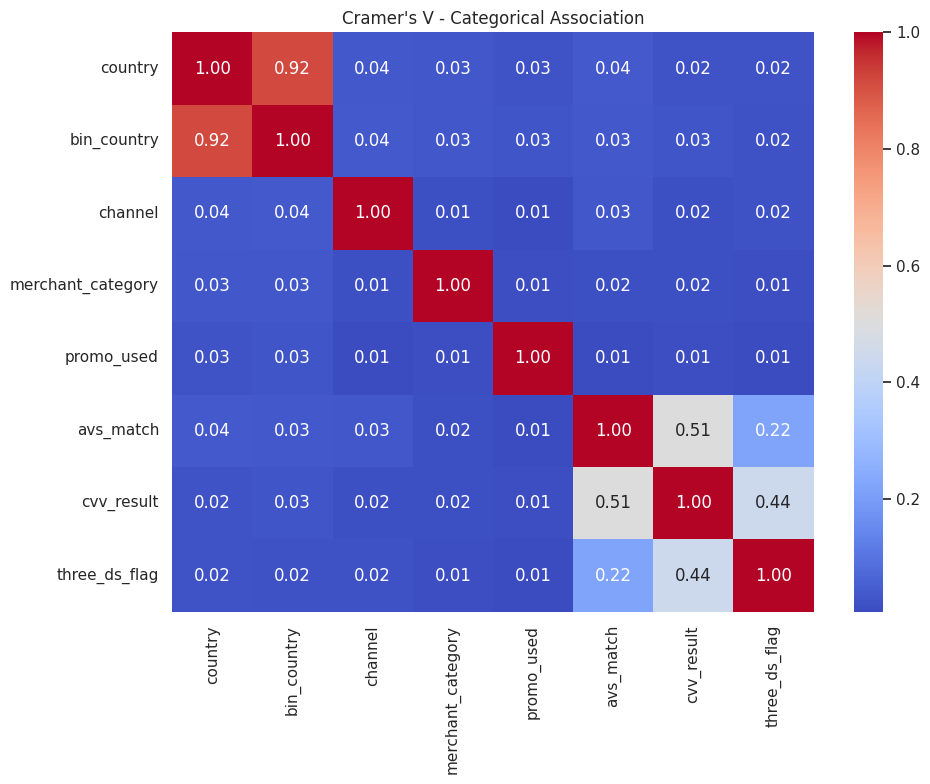

In [40]:
plt.figure(figsize=(10,8))

sns.heatmap(
    cat_corr,
    annot = True,
    fmt = ".2f",
    cmap = "coolwarm"
)

plt.title("Cramer's V - Categorical Association")
plt.tight_layout()
plt.show()

#### Multivariate Analysis

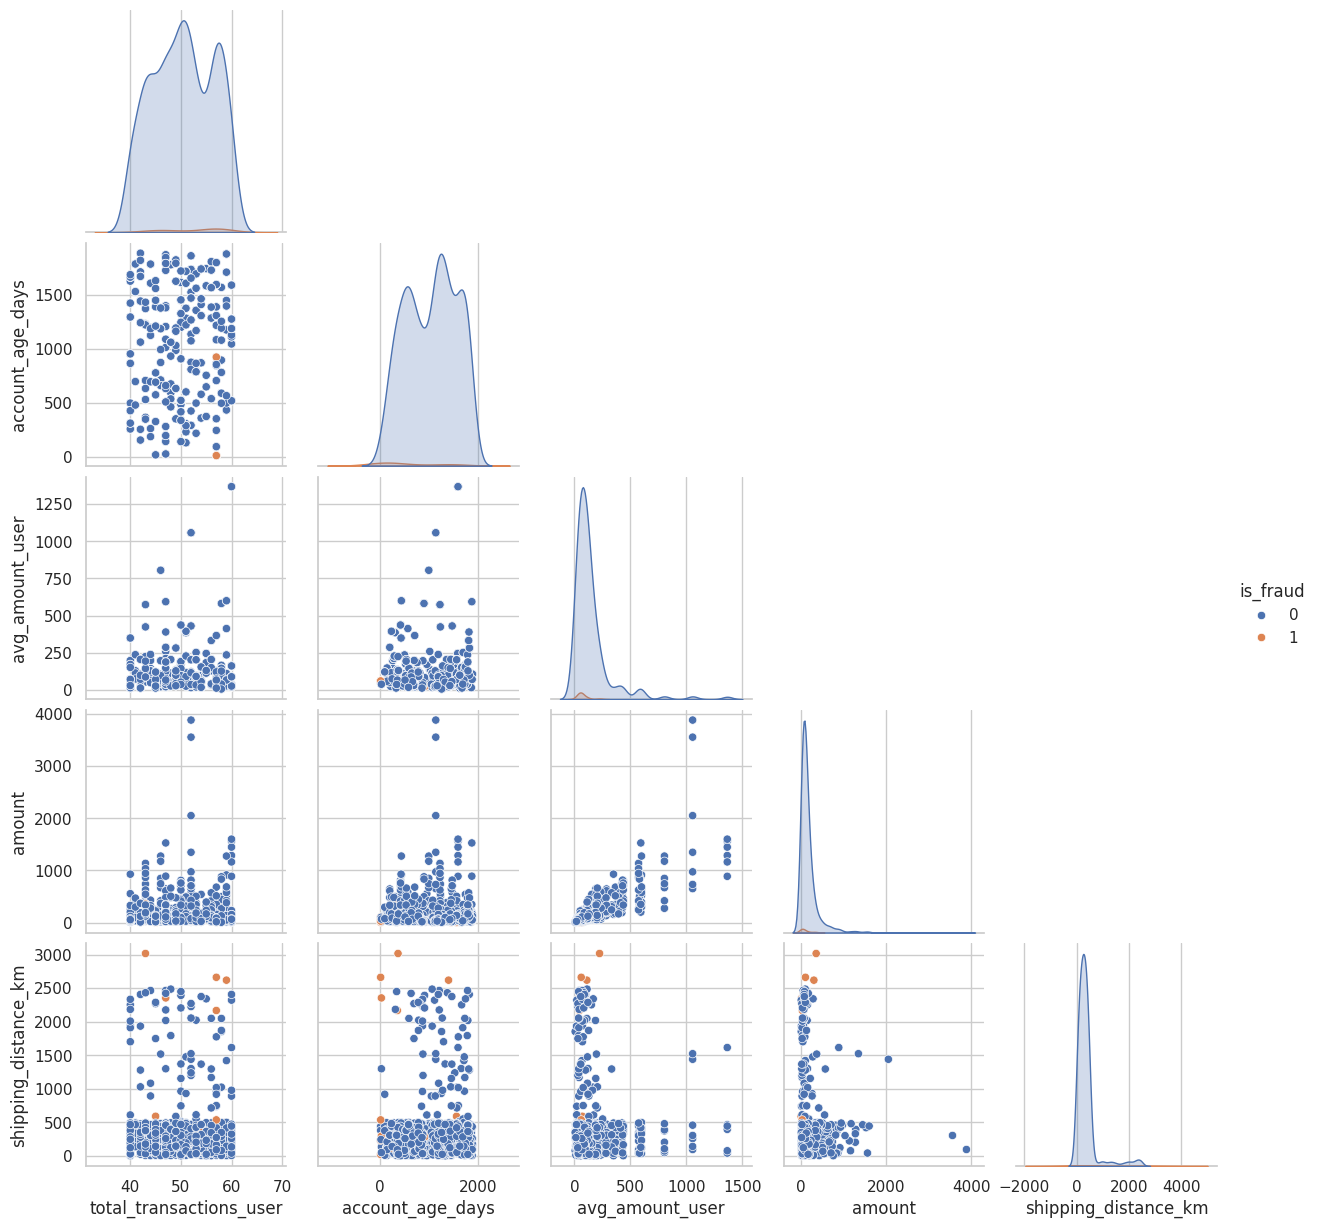

In [41]:
sample_df = df[
    numeric_cols + ["is_fraud"]
].sample(
    min(1000, len(df)),
    random_state = 42
)

sns.pairplot(
    sample_df,
    hue = "is_fraud",
    corner = True
)

plt.show()

In [42]:
df["amount_ratio"] = (
    df["amount"] / df["avg_amount_user"]
)

df["amount_ratio"].describe()

count    9999.000000
mean        1.259447
std         2.414882
min         0.009927
25%         0.716102
50%         1.000169
75%         1.410867
max        79.420965
Name: amount_ratio, dtype: float64

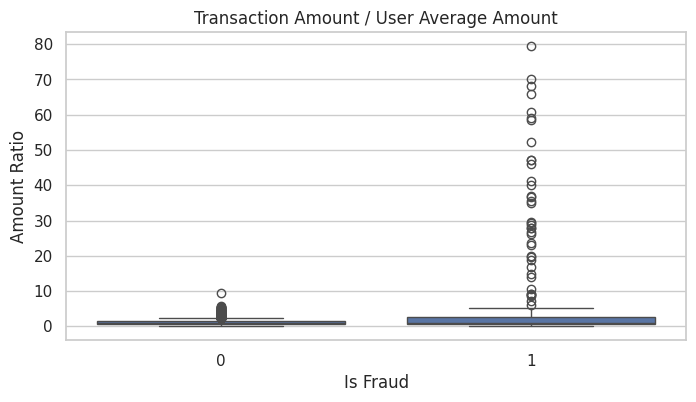

In [43]:
plt.figure(figsize=(8,4))

sns.boxplot(
    data = df,
    x = "is_fraud",
    y = "amount_ratio"
)

plt.title("Transaction Amount / User Average Amount")
plt.xlabel("Is Fraud")
plt.ylabel("Amount Ratio")

plt.show()

In [44]:
df["country_mismatch"] = (
    df["country"] != df["bin_country"]
).astype(int)

pd.crosstab(
    df["country_mismatch"],
    df["is_fraud"],
    normalize= "index"
).mul(100).round(2)

is_fraud,0,1
country_mismatch,,
0,98.89,1.11
1,89.53,10.47


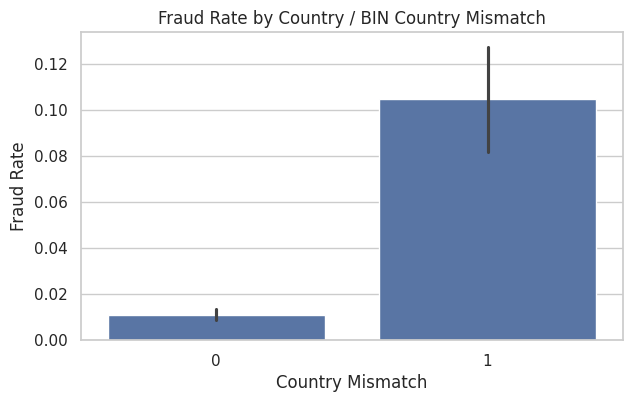

In [45]:
plt.figure(figsize=(7,4))

sns.barplot(
    data = df,
    x = "country_mismatch",
    y = "is_fraud"
)

plt.title("Fraud Rate by Country / BIN Country Mismatch")
plt.xlabel("Country Mismatch")
plt.ylabel("Fraud Rate")

plt.show()

In [46]:
verification_cols = [
    "avs_match",
    "cvv_result",
    "three_ds_flag"
]

df.groupby(verification_cols)["is_fraud"].agg(
    ["count", "mean"]
).sort_values(
    "mean",
    ascending=False
).head(20)

count      mean
avs_match cvv_result three_ds_flag                 
0         0          0                567  0.155203
          1          0                107  0.056075
          0          1                223  0.049327
          1          1                681  0.029369
1         0          0                287  0.027875
          1          0               1211  0.012386
          0          1                126  0.007937
          1          1               6797  0.004708

In [47]:
verification_analysis = (
    df.groupby(verification_cols)["is_fraud"].agg(
        transaction_count = "count",
        fraud_rate = "mean"
    )
)

verification_analysis["fraud_rate"] *= 100

verification_analysis.sort_values(
    "fraud_rate",
    ascending=False
).head(20)

transaction_count  fraud_rate
avs_match cvv_result three_ds_flag                               
0         0          0                            567   15.520282
          1          0                            107    5.607477
          0          1                            223    4.932735
          1          1                            681    2.936858
1         0          0                            287    2.787456
          1          0                           1211    1.238646
          0          1                            126    0.793651
          1          1                           6797    0.470796

#### Outlier Analysis

In [50]:
outlier_summary = []

for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = df[
        (df[col] < lower) |
        (df[col] > upper)
    ]

    outlier_summary.append({
        "column" : col,
        "lower_bound" : lower,
        "upper_bound" : upper,
        "outlier_count" : len(outliers),
        "outlier_percentage" : len(outliers) / len(df) * 100
    })

outlier_summary = pd.DataFrame(outlier_summary)
outlier_summary

,column,lower_bound,upper_bound,outlier_count,outlier_percentage
0,total_transactions_user,31.0000,71.0000,0,0.000000
1,account_age_days,-758.5000,2773.5000,0,0.000000
2,avg_amount_user,-111.7450,303.7350,912,9.120912
3,amount,-157.3525,373.8275,885,8.850885
4,shipping_distance_km,-272.6800,815.8400,639,6.390639


#### Time-based EDA

In [58]:
df["transaction_hour"] = df["transaction_time"].dt.hour
df["transaction_day"] = df["transaction_time"].dt.day_name()
df["transaction_date"] = df["transaction_time"].dt.date
df.head(20)

,transaction_id,user_id,account_age_days,total_transactions_user,avg_amount_user,amount,country,bin_country,channel,merchant_category,promo_used,avs_match,cvv_result,three_ds_flag,transaction_time,shipping_distance_km,is_fraud,amount_ratio,country_mismatch,transaction_hour,transaction_day,transaction_date
0,1,1,141,47,147.93,84.75,FR,FR,web,travel,0,1,1,1,2024-01-06 04:09:39+00:00,370.95,0,0.572906,0,4,Saturday,2024-01-06
1,2,1,141,47,147.93,107.90,FR,FR,web,travel,0,0,0,0,2024-01-09 20:13:47+00:00,149.62,0,0.729399,0,20,Tuesday,2024-01-09
2,3,1,141,47,147.93,92.36,FR,FR,app,travel,1,1,1,1,2024-01-12 06:20:11+00:00,164.08,0,0.624349,0,6,Friday,2024-01-12
3,4,1,141,47,147.93,112.47,FR,FR,web,fashion,0,1,1,1,2024-01-15 17:00:04+00:00,397.40,0,0.760292,0,17,Monday,2024-01-15
4,5,1,141,47,147.93,132.91,FR,US,web,electronics,0,1,1,1,2024-01-17 01:27:31+00:00,935.28,0,0.898465,1,1,Wednesday,2024-01-17
5,6,1,141,47,147.93,224.82,FR,FR,web,travel,0,1,1,1,2024-01-26 22:05:08+00:00,289.06,0,1.519773,0,22,Friday,2024-01-26
6,7,1,141,47,147.93,125.98,FR,FR,app,electronics,0,1,1,1,2024-01-30 00:51:41+00:00,443.75,0,0.851619,0,0,Tuesday,2024-01-30
7,8,1,141,47,147.93,66.95,FR,RO,web,travel,0,1,1,1,2024-02-11 15:33:30+00:00,1390.59,0,0.452579,1,15,Sunday,2024-02-11
8,9,1,141,47,147.93,261.58,FR,FR,app,grocery,0,0,0,0,2024-02-22 01:29:55+00:00,110.51,0,1.768269,0,1,Thursday,2024-02-22
9,10,1,141,47,147.93,97.34,FR,FR,web,electronics,0,0,1,1,2024-03-09 11:13:19+00:00,232.34,0,0.658014,0,11,Saturday,2024-03-09


In [59]:
hourly_fraud = (
    df.groupby("transaction_hour")["is_fraud"].mean().mul(100)
)

hourly_fraud

transaction_hour
0     2.173913
1     2.558635
2     2.631579
3     1.179245
4     1.515152
5     1.897019
6     1.639344
7     1.184834
8     2.863962
9     1.639344
10    2.644231
11    0.733496
12    2.244389
13    1.951220
14    0.709220
15    2.051282
16    2.200489
17    1.869159
18    1.295337
19    0.947867
20    2.078522
21    1.882353
22    1.773836
23    1.703163
Name: is_fraud, dtype: float64

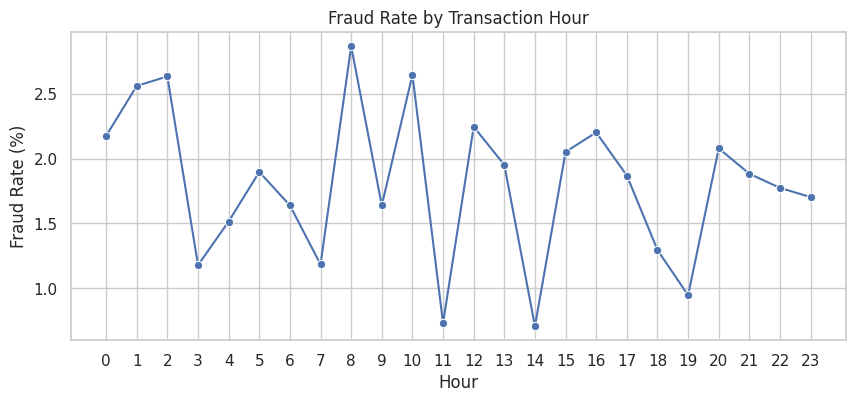

In [62]:
plt.figure(figsize=(10,4))

sns.lineplot(
    x = hourly_fraud.index,
    y = hourly_fraud.values,
    marker = "o"
)

plt.title("Fraud Rate by Transaction Hour")
plt.xlabel("Hour")
plt.ylabel("Fraud Rate (%)")
plt.xticks(range(24))

plt.show()